In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("victorsabanzagil/polymers")

# print("Path to dataset files:", path)

In [4]:
import os
import re
import tempfile
import subprocess
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem import Draw
from gudhi.representations import Landscape
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

FILE_PATH = 'polymers_dataset.csv'
RIPSER_BIN = os.path.abspath("../../ripser/ripser") 

In [5]:
def parse_ripser_cpp_output(output_str, max_death=10.0):
    """Parses textual output from C++ Ripser into lists of persistence intervals [birth, death]."""
    diagrams = {0: [], 1: []}
    current_dim = None
    
    for line in output_str.split('\n'):
        line = line.strip()
        if line.startswith('persistence intervals in dim'):
            current_dim = int(re.search(r'\d+', line).group())
        elif line.startswith('[') and current_dim is not None:
            parts = line.replace('[', '').replace(')', '').split(',')
            birth = float(parts[0])
            death_str = parts[1].strip()
            
            death = max_death if death_str == '' else float(death_str)
            if death > birth:
                if current_dim in diagrams:
                    diagrams[current_dim].append([birth, death])
                    
    return diagrams

def process_single_molecule(idx, smiles, ripser_path):
    """Generates a molecular graph distance matrix using RDKit, runs Ripser, and returns (index, diagrams)."""
    if not isinstance(smiles, str) or not smiles.strip():
        return idx, None
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return idx, None
        
    D = rdmolops.GetDistanceMatrix(mol)
    
    fd, tmp_path = tempfile.mkstemp(suffix='.csv', text=True)
    try:
        with os.fdopen(fd, 'w') as tmp:
            for i in range(D.shape[0]):
                row = D[i, :i]
                tmp.write(",".join(map(str, row)) + "\n")
                
        cmd = [ripser_path, "--format", "lower-distance", "--dim", "2", tmp_path]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        diagrams = parse_ripser_cpp_output(result.stdout)
    except subprocess.CalledProcessError:
        diagrams = None
    finally:
        os.remove(tmp_path)
        
    return idx, diagrams

In [6]:
print("[*] Loading dataset...")
df = pd.read_csv(FILE_PATH)

# Drop duplicates if necessary to prevent data leakage
df = df.drop_duplicates(subset=['smiles']).reset_index(drop=True)

smiles_list = df['smiles'].tolist()
y_raw = df['label'].tolist()

print(f"[*] Computing Vietoris-Rips complexes for {len(smiles_list)} molecules...")
results = Parallel(n_jobs=-1)(
    delayed(process_single_molecule)(idx, smiles, RIPSER_BIN) 
    for idx, smiles in tqdm(enumerate(smiles_list), total=len(smiles_list), desc="Ripser C++")
)

# Filter out errors (e.g., invalid SMILES) and keep valid indices for the baseline
h0_diagrams, h1_diagrams, y_valid, valid_indices = [], [], [], []

for idx, diag in results:
    if diag is not None:
        h0 = np.array(diag[0]) if len(diag[0]) > 0 else np.empty((0,2))
        h1 = np.array(diag[1]) if len(diag[1]) > 0 else np.empty((0,2))
        
        h0_diagrams.append(h0)
        h1_diagrams.append(h1)
        y_valid.append(y_raw[idx])
        valid_indices.append(idx)

print(f"[*] Successfully processed: {len(valid_indices)} samples.")
y_valid = np.array(y_valid)

[*] Loading dataset...
[*] Computing Vietoris-Rips complexes for 20609 molecules...


Ripser C++:   0%|          | 0/20609 [00:00<?, ?it/s]

[*] Successfully processed: 20609 samples.


In [7]:
print("[*] Transforming persistence diagrams to Persistent Landscapes...")

ls_h0 = Landscape(num_landscapes=5, resolution=100)
ls_h1 = Landscape(num_landscapes=5, resolution=100)

X_h0 = ls_h0.fit_transform(h0_diagrams)
X_h1 = ls_h1.fit_transform(h1_diagrams)

X_topological = np.hstack((X_h0, X_h1))
print(f"[*] Topological feature matrix shape: {X_topological.shape}")

[*] Transforming persistence diagrams to Persistent Landscapes...
[*] Topological feature matrix shape: (20609, 1000)


In [8]:
# Option A: Automatic extraction based on numeric column names
feature_cols = [col for col in df.columns if col.isdigit()]
X_baseline = df.loc[valid_indices, feature_cols].values

# Option B: Explicitly dropping metadata columns (uncomment if Option A misses columns)
# cols_to_drop = ['Unnamed: 0', 'smiles', 'label']
# X_baseline = df.iloc[valid_indices].drop(columns=cols_to_drop).values

# Train/Test split using indices to ensure an identical and fair split across models
indices = np.arange(len(valid_indices))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

y_train, y_test = y_valid[train_idx], y_valid[test_idx]
X_train_tda, X_test_tda = X_topological[train_idx], X_topological[test_idx]
X_train_base, X_test_base = X_baseline[train_idx], X_baseline[test_idx]

# --- Model 1: Topological Data Analysis ---
print("\n[*] Training model on TDA features...")
clf_tda = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
clf_tda.fit(X_train_tda, y_train)
y_pred_tda = clf_tda.predict(X_test_tda)

# --- Model 2: Baseline (Raw Features) ---
print("[*] Training model on original features (Baseline)...")
clf_base = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
clf_base.fit(X_train_base, y_train)
y_pred_base = clf_base.predict(X_test_base)

print("\n" + "="*50)
print(" RESULTS: TOPOLOGICAL FEATURES (TDA)")
print("="*50)
print(classification_report(y_test, y_pred_tda))

print("\n" + "="*50)
print(" RESULTS: BASELINE FEATURES (FINGERPRINTS)")
print("="*50)
print(classification_report(y_test, y_pred_base))


[*] Training model on TDA features...
[*] Training model on original features (Baseline)...

 RESULTS: TOPOLOGICAL FEATURES (TDA)
                 precision    recall  f1-score   support

oligosaccharide       0.91      0.96      0.93      1365
        peptide       0.49      0.35      0.41      1356
        plastic       0.55      0.67      0.61      1401

       accuracy                           0.66      4122
      macro avg       0.65      0.66      0.65      4122
   weighted avg       0.65      0.66      0.65      4122


 RESULTS: BASELINE FEATURES (FINGERPRINTS)
                 precision    recall  f1-score   support

oligosaccharide       1.00      1.00      1.00      1365
        peptide       1.00      1.00      1.00      1356
        plastic       1.00      1.00      1.00      1401

       accuracy                           1.00      4122
      macro avg       1.00      1.00      1.00      4122
   weighted avg       1.00      1.00      1.00      4122



In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem.Draw import rdMolDraw2D

# 1. Configuration
# Remember to provide the correct path to your CSV file!
FILE_PATH = 'polymers_dataset.csv'
CLASSES = ['oligosaccharide', 'peptide', 'plastic']
SAMPLES_PER_CLASS = 3

def get_distance_matrix(mol):
    """Calculates the topological shortest-path distance matrix for a molecule."""
    return rdmolops.GetDistanceMatrix(mol)

def mol_to_image(mol, size=(400, 400)):
    """Generates a 2D image of a molecule with explicit atom indices."""
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    
    # --- KEY CHANGE HERE ---
    options = drawer.drawOptions()
    options.addAtomIndices = True  # Enables atom numbering (0, 1, 2...)
    options.annotationFontScale = 0.8  # Optional: adjust the size of atom indices
    
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    
    from PIL import Image
    import io
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

print("[*] Loading dataset...")
# Ensure the column names match: 'smiles' and 'label'
try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"[!] File {FILE_PATH} not found. Check the path.")
    # Simulate program termination
    import sys
    sys.exit()

# Prepare the output directory
os.makedirs('plymers_plots', exist_ok=True)

print(f"[*] Starting generation of {SAMPLES_PER_CLASS} samples for {len(CLASSES)} classes...\n")

for cls in CLASSES:
    # Fetch the first X records for a given class (X = SAMPLES_PER_CLASS)
    subset = df[df['label'] == cls].head(SAMPLES_PER_CLASS)
    
    if len(subset) < SAMPLES_PER_CLASS:
        print(f"[!] Not enough samples in class {cls} ({len(subset)}). Required: {SAMPLES_PER_CLASS}")
        continue
    
    # Initialize the panel: 2 rows (Molecule, Matrix), SAMPLES_PER_CLASS columns
    fig, axes = plt.subplots(nrows=2, ncols=SAMPLES_PER_CLASS, figsize=(15, 10))
    fig.suptitle(f"Polymer Class: {cls.upper()}", fontsize=20, y=0.98)
    
    for idx, (index, row) in enumerate(subset.iterrows()):
        smiles_str = row['smiles']
        mol = Chem.MolFromSmiles(smiles_str)
        
        if mol is None:
            print(f"  [!] RDKit could not parse SMILES: {smiles_str}")
            continue
            
        # -- ROW 0: Molecule --
        ax_mol = axes[0, idx]
        img = mol_to_image(mol, size=(400, 400))
        ax_mol.imshow(img)
        ax_mol.axis('off') # Hide axes around the image
        ax_mol.set_title(f"Sample {idx+1}\nAtoms: {mol.GetNumAtoms()}", fontsize=12)
        
        # -- ROW 1: Distance Matrix --
        ax_mat = axes[1, idx]
        dist_mat = get_distance_matrix(mol)
        
        # Set xticklabels and yticklabels to True
        sns.heatmap(
            dist_mat, 
            ax=ax_mat, 
            cmap='magma',     
            cbar=True,        
            square=True,      
            xticklabels=True,  # <--- X-axis labels enabled
            yticklabels=True   # <--- Y-axis labels enabled
        )
        
        # Drastically reduce axis label font size (e.g., to 6 or 7 points) 
        # so atom indices fit next to each other when there are many atoms
        ax_mat.tick_params(axis='both', which='major', labelsize=6)
        ax_mat.set_title("Distance Matrix D(V,E)", fontsize=12)
        
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust margins to fit the main title at the top
    
    # Save
    filename = f"plymers_plots/matrix_analysis_{cls}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight') # dpi 150 - high quality for documents
    print(f"[+] Saved: {filename}")
    
    # Matplotlib keeps windows open in a pure script, clear memory before the next class
    plt.close(fig)

print("\n[*] Process completed. Images are saved in the 'plymers_plots' folder.")

[*] Loading dataset...
[*] Starting generation of 3 samples for 3 classes...

[+] Saved: plymers_plots/matrix_analysis_oligosaccharide.png
[+] Saved: plymers_plots/matrix_analysis_peptide.png
[+] Saved: plymers_plots/matrix_analysis_plastic.png

[*] Process completed. Images are saved in the 'plymers_plots' folder.


In [ ]:
from persim import plot_diagrams
from persim.landscapes import PersLandscapeApprox, plot_landscape_simple

In [ ]:
print("[*] Transforming persistence diagrams to Persistent Landscapes...")

ls_h0 = Landscape(num_landscapes=5, resolution=100)
ls_h1 = Landscape(num_landscapes=5, resolution=100)

X_h0 = ls_h0.fit_transform(h0_diagrams)
X_h1 = ls_h1.fit_transform(h1_diagrams)

X_topological = np.hstack((X_h0, X_h1))
print(f"[*] Topological feature matrix shape: {X_topological.shape}")

[*] Transforming persistence diagrams to Persistent Landscapes...
[*] Topological feature matrix shape: (20609, 1000)


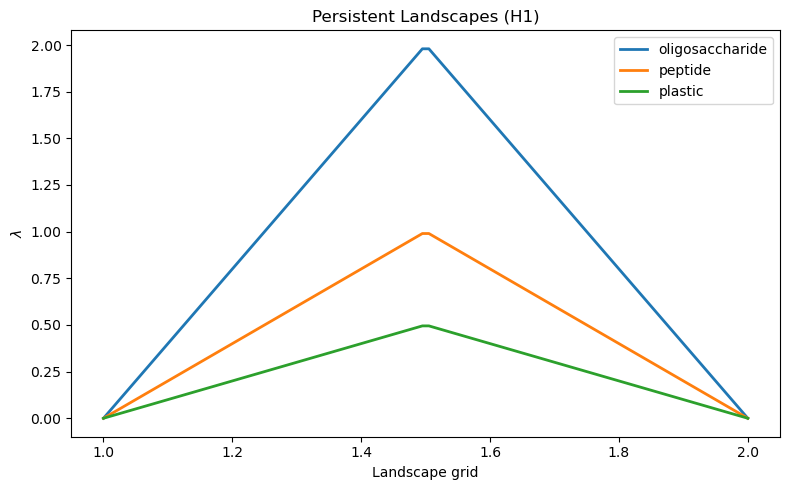

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from persim.landscapes import PersLandscapeApprox

classes = ["oligosaccharide", "peptide", "plastic"]

n_steps = 100  
n_landscapes = 5

plt.figure(figsize=(8, 5))

for cls in classes:
    # Find the first index corresponding to the current class
    idx = np.where(np.array(y_valid) == cls)[0][0]
    diagram = h1_diagrams[idx]

    # Safe fallback for empty diagrams to prevent skipping the class
    # An empty array will be replaced with a zero-persistence point to draw a flat baseline
    if diagram.shape[0] == 0:
        diagram = np.array([[0.0, 0.0]])

    # Initialize the approximate persistent landscape
    pl = PersLandscapeApprox(
        dgms=[None, diagram],
        hom_deg=1,  # FIXED: Changed from 0 to 1 to match H1 diagrams
        num_steps=n_steps
    )

    # Generate the x-axis grid based on the landscape's support
    x = np.linspace(pl.start, pl.stop, pl.num_steps)
    landscape = pl.values

    # Plot the cumulative sum of the first n_landscapes
    plt.plot(
        x,
        np.sum(landscape[:n_landscapes], axis=0),
        linewidth=2,
        label=cls
    )

plt.xlabel("Landscape grid")
plt.ylabel(r"$\lambda$")
plt.title("Persistent Landscapes (H1)")
plt.legend()
plt.tight_layout()

# Ensure the output directory exists before saving
os.makedirs("plymers_plots", exist_ok=True)
plt.savefig("plymers_plots/persistent_landscapes.png", dpi=150)
plt.show()

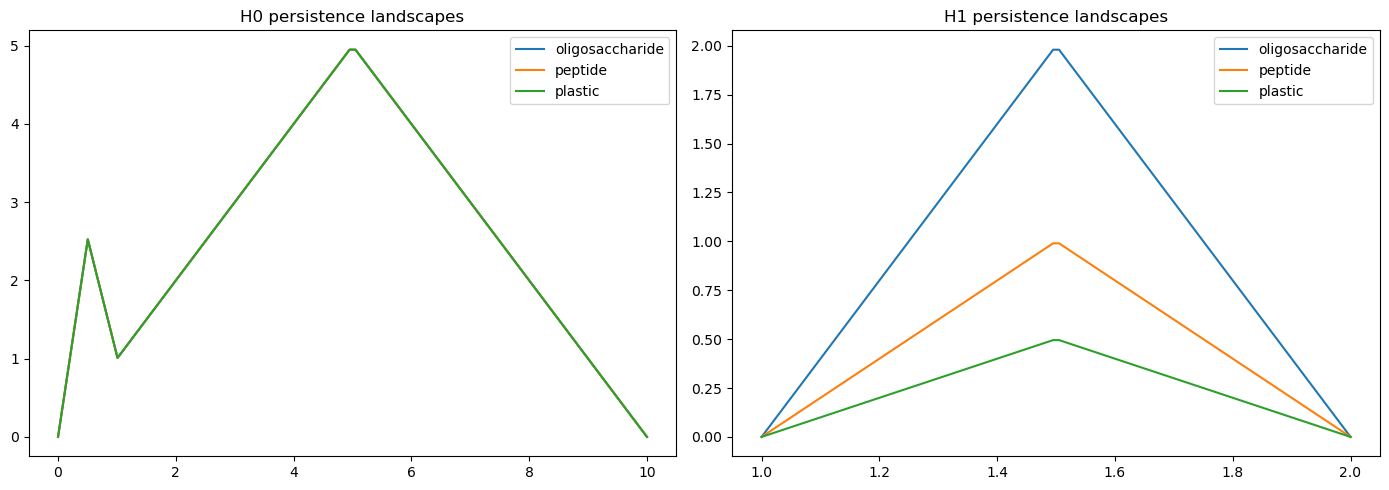

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in classes:
    idx = np.where(np.array(y_valid) == cls)[0][0]

    # ===== H0 =====
    pl0 = PersLandscapeApprox(
        dgms=[h0_diagrams[idx]],
        hom_deg=0,
        num_steps=n_steps
    )

    x0 = np.linspace(pl0.start, pl0.stop, pl0.num_steps)
    axes[0].plot(
        x0,
        np.sum(pl0.values[:n_landscapes], axis=0),
        label=cls
    )

    # ===== H1 =====
    pl1 = PersLandscapeApprox(
        dgms=[h1_diagrams[idx]],
        hom_deg=0,
        num_steps=n_steps
    )

    x1 = np.linspace(pl1.start, pl1.stop, pl1.num_steps)
    axes[1].plot(
        x1,
        np.sum(pl1.values[:n_landscapes], axis=0),
        label=cls
    )

axes[0].set_title("H0 persistence landscapes")
axes[1].set_title("H1 persistence landscapes")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

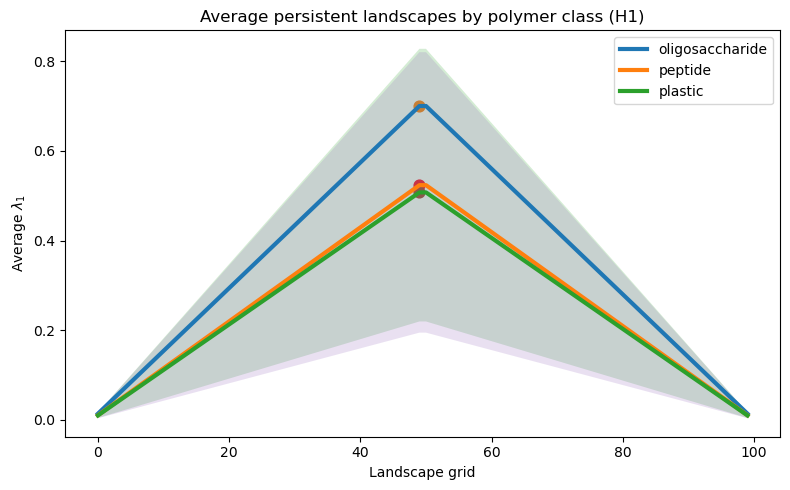

In [ ]:
plt.figure(figsize=(8,5))

for cls in classes:

    idx = np.where(np.array(y_raw) == cls)[0]

    landscapes = X_h1[idx, :resolution]

    mean_landscape = landscapes.mean(axis=0)
    std_landscape = landscapes.std(axis=0)

    plt.plot(
        x,
        mean_landscape,
        linewidth=3,
        label=cls
    )

    plt.fill_between(
        x,
        mean_landscape - std_landscape,
        mean_landscape + std_landscape,
        alpha=0.2
    )

    peak_idx = np.argmax(mean_landscape)

    plt.scatter(
        x[peak_idx],
        mean_landscape[peak_idx],
        s=60
    )

plt.xlabel("Landscape grid")
plt.ylabel(r"Average $\lambda_1$")
plt.title("Average persistent landscapes by polymer class (H1)")
plt.legend()
plt.tight_layout()

plt.savefig("landscape_means.pdf")
plt.show()

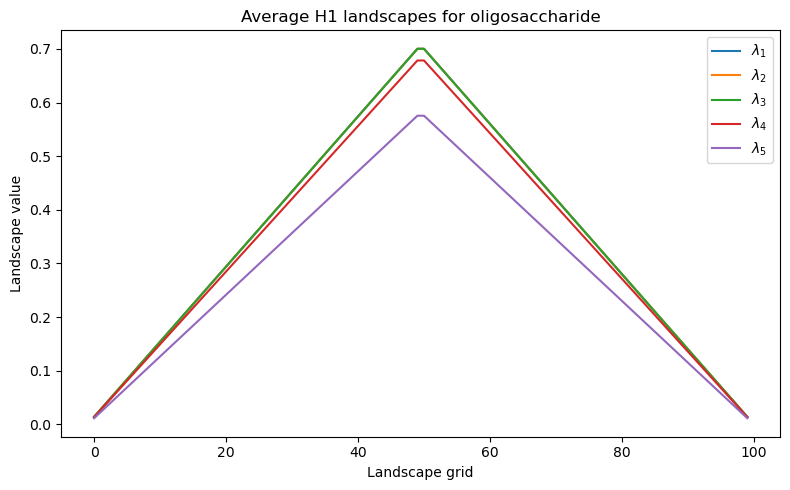

In [ ]:
cls = "oligosaccharide"

idx = np.where(np.array(y_raw) == cls)[0]

mean_landscapes = X_h1[idx].mean(axis=0).reshape(5, 100)

plt.figure(figsize=(8,5))

for k in range(5):
    plt.plot(
        x,
        mean_landscapes[k],
        label=rf"$\lambda_{{{k+1}}}$"
    )

plt.xlabel("Landscape grid")
plt.ylabel("Landscape value")
plt.title(f"Average H1 landscapes for {cls}")
plt.legend()
plt.tight_layout()
plt.show()